<a href="https://colab.research.google.com/github/BenWu-Open/Medical-Image-Code/blob/main/L8_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Thresholding
Convert a grey scale image to it's binary

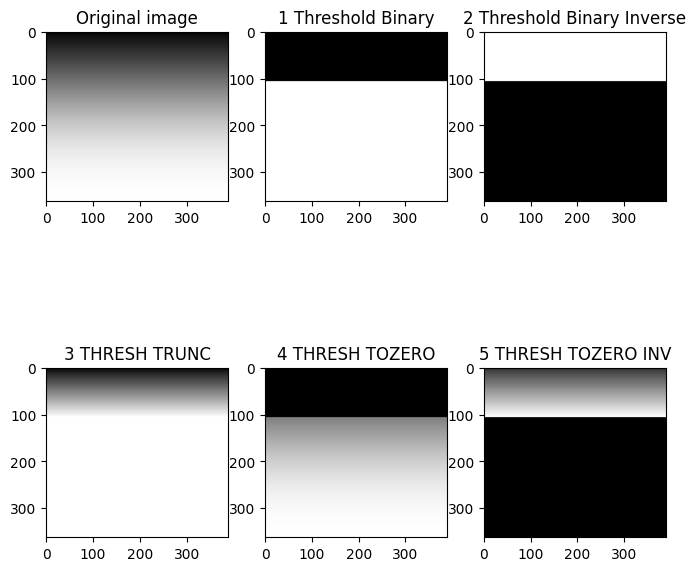

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load our image as greyscale
image = cv2.imread('gradient.jpg',0)
#cv2.imshow('Original', image)

# Values below 127 goes to 0 (black, everything above goes to 255 (white)

ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

#cv2.imshow('1 Threshold Binary', thresh1)

# Values below 127 go to 255 and values above 127 go to 0 (reverse of above)

ret,thresh2 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY_INV)

#cv2.imshow('2 Threshold Binary Inverse', thresh2)

# Values above 127 are truncated (held) at 127 (the 255 argument is unused)

ret,thresh3 = cv2.threshold(image, 127, 255, cv2.THRESH_TRUNC)

#cv2.imshow('3 THRESH TRUNC', thresh3)

# Values below 127 go to 0, above 127 are unchanged

ret,thresh4 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO)

#cv2.imshow('4 THRESH TOZERO', thresh4)


# Resever of above, below 127 is unchanged, above 127 goes to 0

ret,thresh5 = cv2.threshold(image, 127, 255, cv2.THRESH_TOZERO_INV)
#cv2.imshow('5 THRESH TOZERO INV', thresh5)
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax6 = fig.add_subplot(236)

ax1.set_title('Original image')
ax1.imshow(image, cmap='gray')
ax2.set_title('1 Threshold Binary')
ax2.imshow(thresh1, cmap='gray')
ax3.set_title('2 Threshold Binary Inverse')
ax3.imshow(thresh2, cmap='gray')
ax4.set_title('3 THRESH TRUNC')
ax4.imshow(thresh3, cmap='gray')
ax5.set_title('4 THRESH TOZERO')
ax5.imshow(thresh4, cmap='gray')
ax6.set_title('5 THRESH TOZERO INV')
ax6.imshow(thresh5, cmap='gray')

Adaptive Thresholding

'\ncv2.waitKey(0) \ncv2.destroyAllWindows()\nfor i in range(2):\n    cv2.waitKey(1)\n'

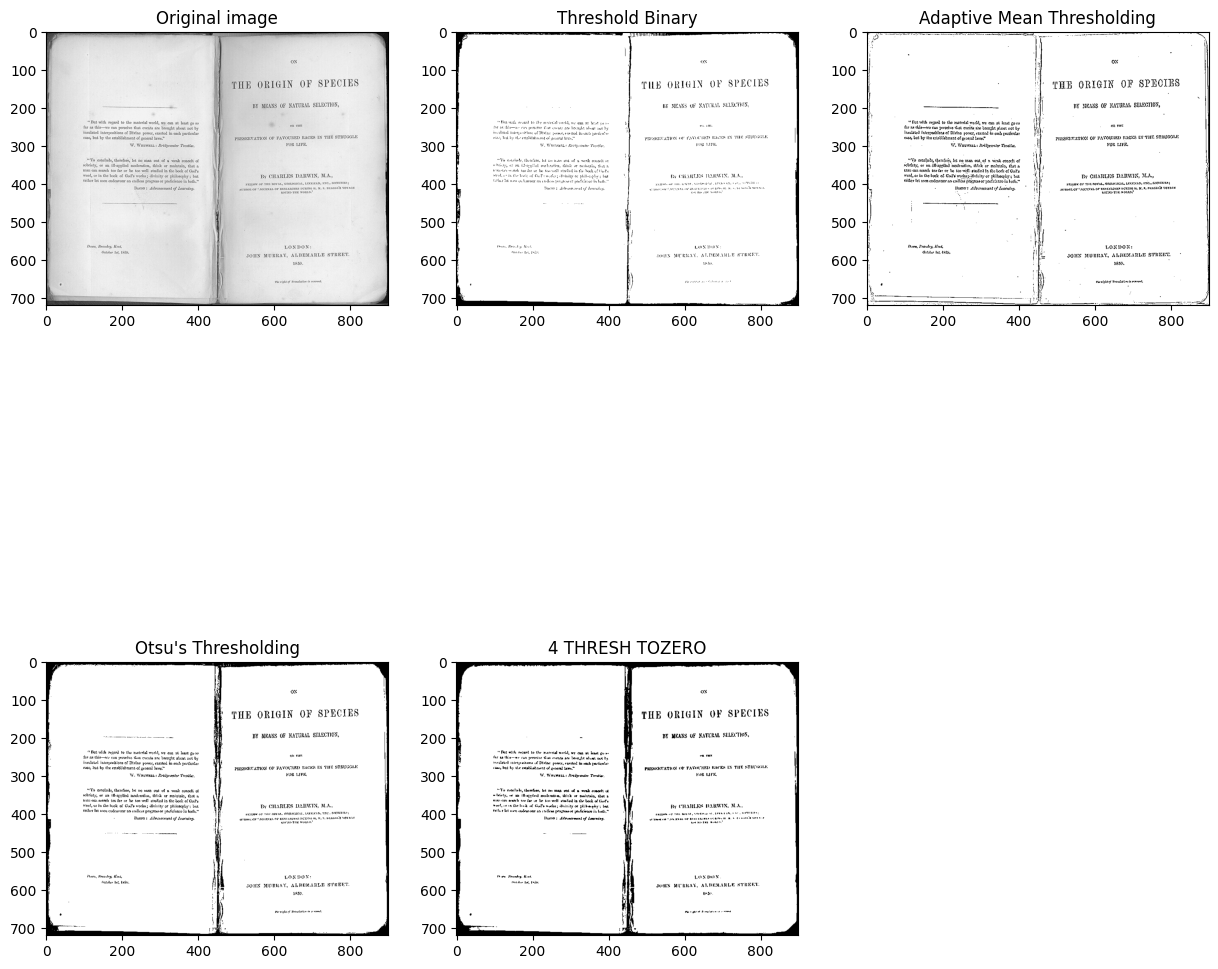

In [ ]:
import cv2
import numpy as np

# Load 加載 圖像
image = cv2.imread('Origin_of_Species.jpg', 0)

#cv2.imshow('Original', image)
#cv2.waitKey(0)


#  Values below 127 goes to 0 (black, everything above goes to 255 (white)


ret,thresh1 = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
#cv2.imshow('Threshold Binary', thresh1)
#cv2.waitKey(0)


# It's good practice to blur images as it removes noise


gblur = cv2.GaussianBlur(image, (3, 3), 0)


# Using adaptiveThreshold

th2 = cv2.adaptiveThreshold(gblur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                               cv2.THRESH_BINARY, 3, 5)
#cv2.imshow("Adaptive Mean Thresholding", thresh)
#cv2.waitKey(0)

_, th3 = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#cv2.imshow("Otsu's Thresholding", thresh)
#cv2.waitKey(0)

# Otsu's thresholding after Gaussian filtering


blur = cv2.GaussianBlur(image, (3,3), 0)
_, th4 = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#cv2.imshow("Guassian Otsu's Thresholding", thresh)

fig = plt.figure(figsize=(15,15))
ax1 = fig.add_subplot(231)
ax2 = fig.add_subplot(232)
ax3 = fig.add_subplot(233)
ax4 = fig.add_subplot(234)
ax5 = fig.add_subplot(235)
ax1.set_title('Original image')
ax1.imshow(image, cmap='gray')
ax2.set_title('Threshold Binary')
ax2.imshow(thresh1, cmap='gray')
ax3.set_title('Adaptive Mean Thresholding')
ax3.imshow(th2, cmap='gray')
ax4.set_title('Otsu\'s Thresholding')
ax4.imshow(th3, cmap='gray')
ax5.set_title('4 THRESH TOZERO')
ax5.imshow(th4, cmap='gray')





Line Detection - Hough Lineslines.
  
cv2.HoughLines(image, rho, theta, threshold[, lines[, srn[, stn[, min_theta[, max_theta]]]]])

image: Input image; must be an 8-bit grayscale image (usually the binary output of Canny edge detection).   
  
rho: Distance resolution of the accumulator in pixels (scanning step for $\rho$).  
  
theta: Angle resolution of the accumulator in radians (scanning step for $\theta$).    
  
threshold: The accumulator threshold. Only lines that receive more than threshold votes are returned.
  
lines: The output vector of lines. Each line is represented by a $(\rho, \theta)$ pair.  
  
srn: Used for Multi-Scale Hough Transform. It is the divisor for rho. Set to 0 for the Classical Hough Transform.  
  
stn: Used for Multi-Scale Hough Transform. It is the divisor for theta. Set to 0 for the Classical Hough Transform.
  
min_theta: Minimum angle to check for lines (in radians).
  
max_theta: Maximum angle to check for lines (in radians).     
  
Note: The output lines provides $(\rho, \theta)$, where $\rho$ is the perpendicular distance from the origin ($0,0$) and $\theta$ is the angle in radians.  
  
*******************************************************************************.   
  
HoughLinesP (Probabilistic).
lines = cv2.HoughLinesP(image, rho, theta, threshold[, lines[, minLineLength[, maxLineGap]]]).
  
minLineLength: Minimum length of a line. Line segments shorter than this are rejected.  
  
maxLineGap: Maximum allowed gap between line segments to treat them as a single line (useful for obstructed boundaries).  

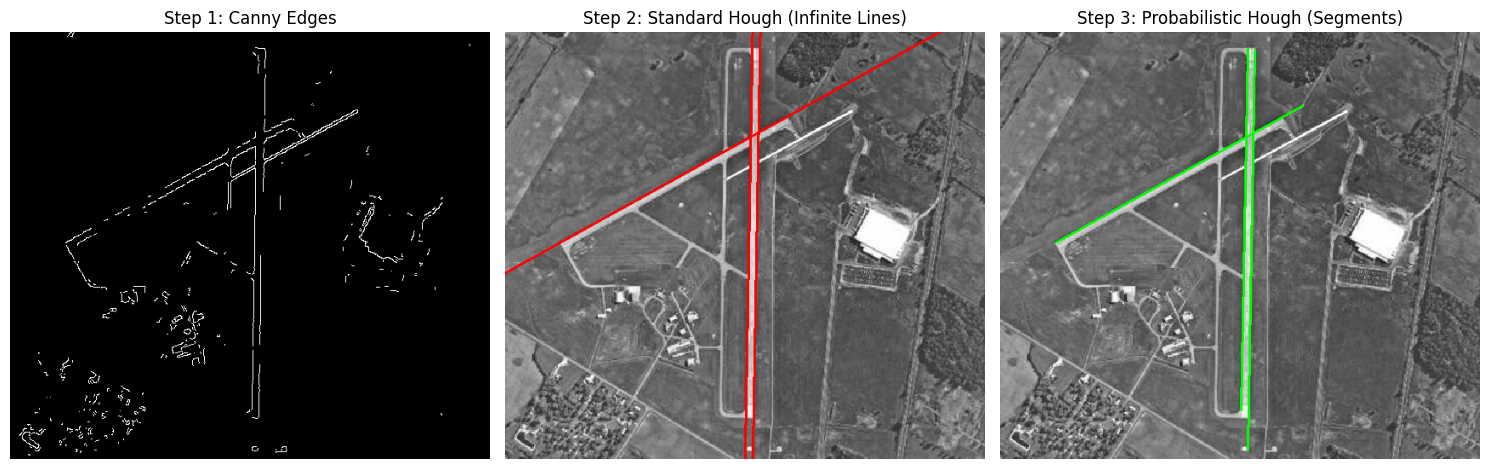

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image and convert to grayscale
# Replace 'headCT.tif' with your actual file path
img = cv2.imread('airport.tif')
if img is None:
    print("Error: Could not load image.")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Edge Detection (Prerequisite step for Hough Transform)
    edges = cv2.Canny(gray, 400, 500, apertureSize=3)

    # Create copies of the original image to draw results on
    img_std = img.copy()
    img_prob = img.copy()

    # 3. Standard Hough Line Transform (cv2.HoughLines)
    # Output is in polar coordinates (rho, theta) representing infinite lines
    lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=120)

    if lines is not None:
        for line in lines:
            rho, theta = line[0]
            a = np.cos(theta)
            b = np.sin(theta)
            x0 = a * rho
            y0 = b * rho
            # Calculate two distant points to draw an "infinite" line across the frame
            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * (a))
            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * (a))
            cv2.line(img_std, (x1, y1), (x2, y2), (0, 0, 255), 2) # Red lines

    # 4. Probabilistic Hough Line Transform (cv2.HoughLinesP)
    # Output directly provides segment endpoints (x1, y1, x2, y2)
    lines_p = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=120,
                              minLineLength=50, maxLineGap=210)

    if lines_p is not None:
        for line in lines_p:
            x1, y1, x2, y2 = line[0]
            cv2.line(img_prob, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green lines

    # 5. Visualization of Results
    plt.figure(figsize=(15, 5))

    plt.subplot(131)
    plt.imshow(edges, cmap='gray')
    plt.title('Step 1: Canny Edges')
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(cv2.cvtColor(img_std, cv2.COLOR_BGR2RGB))
    plt.title('Step 2: Standard Hough (Infinite Lines)')
    plt.axis('off')

    plt.subplot(133)
    plt.imshow(cv2.cvtColor(img_prob, cv2.COLOR_BGR2RGB))
    plt.title('Step 3: Probabilistic Hough (Segments)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

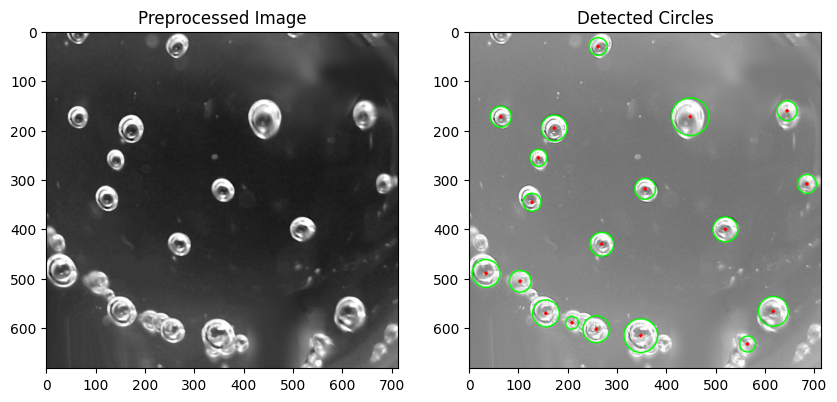

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image and convert to grayscale
# For medical imaging, this could be a cross-section of a vessel or a tumor
img = cv2.imread('bubbles.tif')
if img is None:
    print("Error: Image not found.")
else:
    output = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Preprocessing: Median Blur is often better than Gaussian for circles
    # It removes salt-and-pepper noise while preserving edges
    gray_blurred = cv2.medianBlur(gray, 5)

    # 3. Apply Hough Circle Transform
    # parameters: (image, method, dp, minDist, param1, param2, minRadius, maxRadius)
    circles = cv2.HoughCircles(
        gray_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,          # Inverse ratio of accumulator resolution
        minDist=50,      # Minimum distance between the centers of detected circles
        param1=100,      # Higher threshold for the internal Canny edge detector
        param2=30,       # Accumulator threshold (smaller = more circles detected)
        minRadius=10,    # Minimum circle radius
        maxRadius=60    # Maximum circle radius
    )

    # 4. Draw the detected circles
    if circles is not None:
        # Convert the (1, N, 3) array to (N, 3) and round to integers
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            # Draw the outer circle (Green)
            cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Draw the center of the circle (Red)
            cv2.circle(output, (i[0], i[1]), 2, (0, 0, 255), 3)

    # 5. Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.imshow(gray_blurred, cmap='gray'), plt.title('Preprocessed Image')
    plt.subplot(122), plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)), plt.title('Detected Circles')
    plt.show()

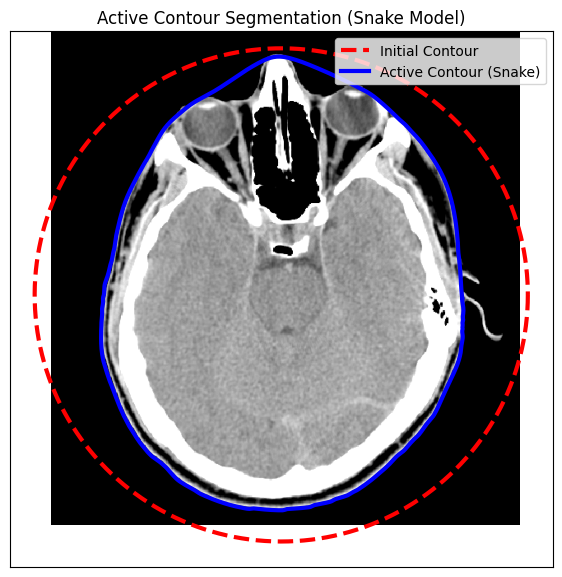

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import data, filters
from skimage.segmentation import active_contour
import cv2

# --- Step 1: Image Preparation ---
# Load the target medical image in grayscale.
# In clinical practice, preprocessing like contrast enhancement may be required.
img = cv2.imread('headCT.tif', 0)

# --- Step 2: Contour Initialization (Initial Snake) ---
# We define a circular boundary near the object of interest to act as the starting 'Snake'.
# Note: The Snake is a local optimizer; the initial position must be close to the target boundary.
center_y, center_x = 320, 280
radius = 300

# Generate 600 points to ensure high resolution for the contour.
# Increasing the number of points (N=600) allows the snake to fit complex, irregular edges.
s = np.linspace(0, 2*np.pi, 600)
y = center_y + radius * np.sin(s)
x = center_x + radius * np.cos(s)

# Combine into an (N, 2) NumPy array.
# Scikit-image uses the (row, column) format, which corresponds to (y, x).
init_coords = np.array([y, x]).T


# --- Step 3: Execute the Active Contour Algorithm ---
# We apply a Gaussian filter first to smooth noise, which prevents the snake
# from getting stuck in local intensity 'pits' (noise).
#
# Parameter Definitions:
# alpha: Elasticity (Internal Energy). High values make the snake contract like a tight rubber band.
# beta: Smoothness (Internal Energy). High values prevent sharp corners or 'jagged' edges.
# w_line: Attraction to brightness/darkness. Set to 0 if only interested in edges.
# w_edge: Attraction to gradients (External Energy). Set to 1 to pull the snake toward sharp boundaries.
# gamma: Time step for the numerical solver.
snake = active_contour(filters.gaussian(img, 3, preserve_range=False),
                       init_coords,
                       alpha=0.015,
                       beta=10,
                       w_line=0,
                       w_edge=1,
                       gamma=0.001)

# --- Step 4: Result Visualization ---
# We display the original image with both the initial 'seed' contour and the final fitted result.
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)

# Plotting the red dashed line representing the user-defined starting position
ax.plot(init_coords[:, 1], init_coords[:, 0], '--r', lw=3, label='Initial Contour')

# Plotting the blue solid line representing the converged boundary after energy minimization
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=3, label='Active Contour (Snake)')

# Clean up axes for a professional presentation look
ax.set_xticks([]), ax.set_yticks([])
ax.axis('image')
ax.legend(loc='upper right')
plt.title("Active Contour Segmentation (Snake Model)")

plt.show()

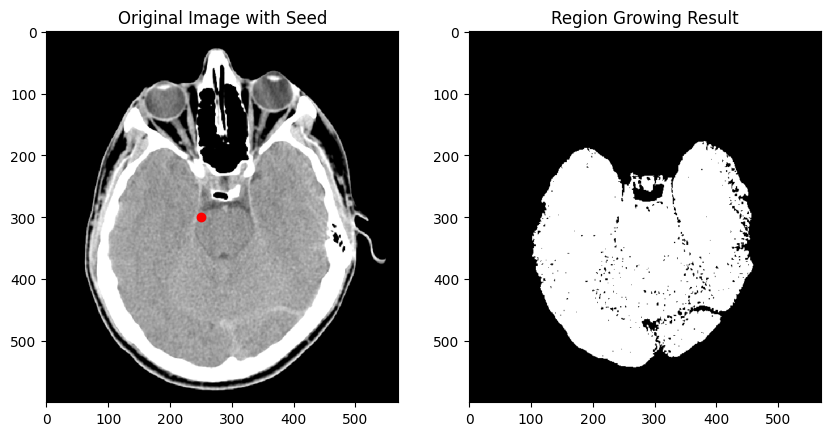

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def region_growing(img, seed, threshold):
    """
    img: Grayscale input image
    seed: (y, x) coordinates of the starting point
    threshold: Maximum intensity difference to include a neighbor
    """
    # Get image dimensions
    rows, cols = img.shape
    # Create an empty mask to store the grown region
    segmented_img = np.zeros_like(img)

    # List of pixels to check (the "frontline" of growth)
    seed_points = [seed]
    # Keep track of visited pixels to avoid infinite loops
    visited = np.zeros_like(img, dtype=bool)

    # Define 8-connectivity (neighbors: top, bottom, left, right, and diagonals)
    neighbors = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

    # Get the intensity of the starting seed point
    region_mean = img[seed[0], seed[1]]

    while len(seed_points) > 0:
        # Pop the last point from the list
        curr_y, curr_x = seed_points.pop()

        # Mark as segmented
        segmented_img[curr_y, curr_x] = 255

        # Check all 8 neighbors
        for dy, dx in neighbors:
            ny, nx = curr_y + dy, curr_x + dx

            # Ensure the neighbor is within image boundaries
            if 0 <= ny < rows and 0 <= nx < cols:
                # Check if pixel was already visited
                if not visited[ny, nx]:
                    # Similarity Criterion: Difference between neighbor and seed intensity
                    if abs(int(img[ny, nx]) - int(region_mean)) < threshold:
                        segmented_img[ny, nx] = 255
                        seed_points.append((ny, nx))

                    # Mark pixel as visited regardless of whether it was added to region
                    visited[ny, nx] = True

    return segmented_img

# --- Main Execution ---
# 1. Load image in grayscale
image = cv2.imread('headCT.tif', 0)

# 2. Define a Seed Point (y, x)
# Note: In a clinical app, this is often selected by a mouse click
seed_point = (300, 250)

# 3. Set the similarity threshold
# Lower = more restrictive (smaller region); Higher = more inclusive (larger region)
threshold_value = 50

# 4. Run the algorithm
result = region_growing(image, seed_point, threshold_value)

# 5. Visualization
plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(image, cmap='gray'), plt.title('Original Image with Seed')
plt.plot(seed_point[1], seed_point[0], 'ro') # Mark the seed point
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Region Growing Result')
plt.show()

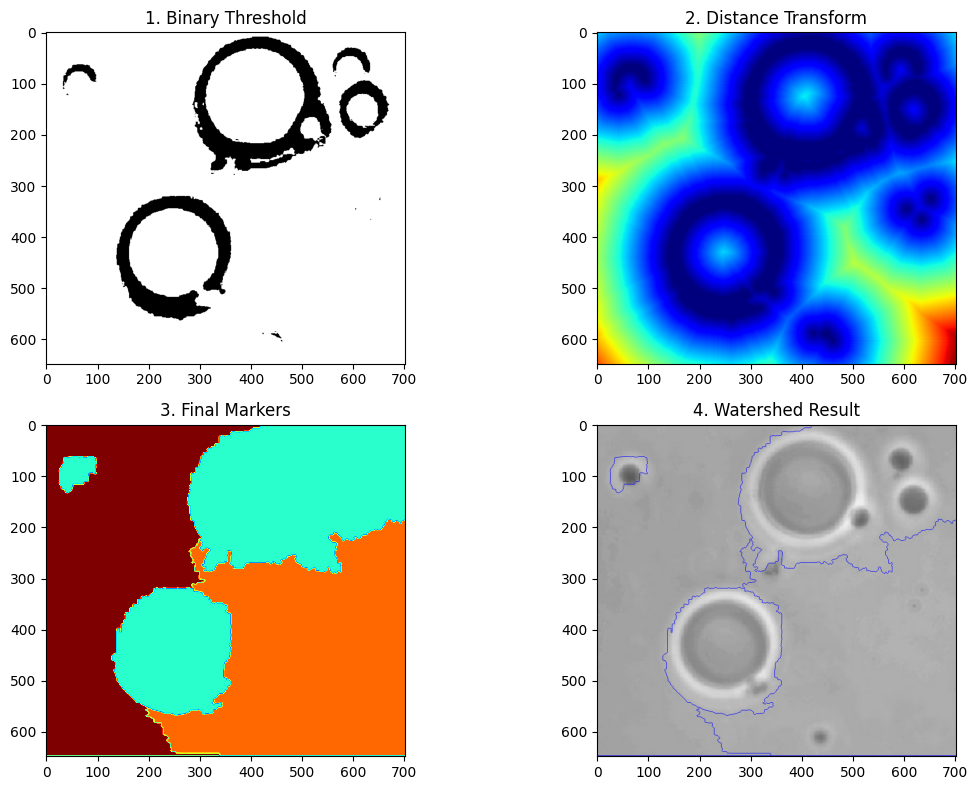

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Image Loading and Preprocessing ---
# We load the image and apply a threshold to create a binary image.
img = cv2.imread('polymercell.tif')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Apply Otsu's thresholding to separate the main object from the background
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# --- Step 2: Noise Removal ---
# We use morphological opening (erosion followed by dilation) to remove small white noise.
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# --- Step 3: Determining Background and Foreground ---
# 1. Sure Background Area: Dilate the image to ensure the black areas are definitely background.
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# 2. Sure Foreground Area: Use Distance Transform.
# Pixels furthest from the boundaries are definitely part of the objects.
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
# We threshold the distance transform to get the core "seeds" of the objects.
ret, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

# 3. Unknown Region: The area between the sure background and sure foreground.
# This is where the Watershed algorithm will find the "dams" (boundaries).
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# --- Step 4: Marker Labeling ---
# Connected components labels the "seeds" with unique integers.
ret, markers = cv2.connectedComponents(sure_fg)

# Add 1 to all labels so that sure background is 1 instead of 0.
markers = markers + 1

# Mark the unknown region with 0. These are the areas the algorithm will decide.
markers[unknown == 255] = 0

# --- Step 5: Execute Watershed ---
# The algorithm "floods" the image from the markers.
# When different "waters" meet, it builds a dam (boundary).
markers = cv2.watershed(img, markers)

# Markers with value -1 represent the boundaries (the "dams").
img[markers == -1] = [255, 0, 0] # Draw boundaries in Red

# --- Step 6: Result Visualization ---
plt.figure(figsize=(12, 8))
plt.subplot(221), plt.imshow(thresh, cmap='gray'), plt.title('1. Binary Threshold')
plt.subplot(222), plt.imshow(dist_transform, cmap='jet'), plt.title('2. Distance Transform')
plt.subplot(223), plt.imshow(markers, cmap='jet'), plt.title('3. Final Markers')
plt.subplot(224), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title('4. Watershed Result')
plt.tight_layout()
plt.show()

### <font color='cyan'> HW1</font>
1.  Read "angiogram-aortic-kidney.tif" \(left\)  
2. Use any method to segment the main aorta .
3. Display the results (mask).



In [ ]:
'''
Please write the code below

'''

### <font color='cyan'> HW2</font>
1.  Read "bubbles.tif" \(left\)  
2. Use any method to segment the bubbles .
3. Display the results (mask).



In [ ]:
'''
Please write the code below

'''

### <font color='cyan'> HW3</font>
1.  Read "yeast-cells.tif" \(left\)  
2. Use any method to segment the cells .
3. Display the results (mask).

In [ ]:
'''
Please write the code below

'''

### <font color='cyan'> HW4</font>
1.  Read "breastXray.tif" \(left\)  
2. Use any method to segment the breast.
3. Display the results (mask).


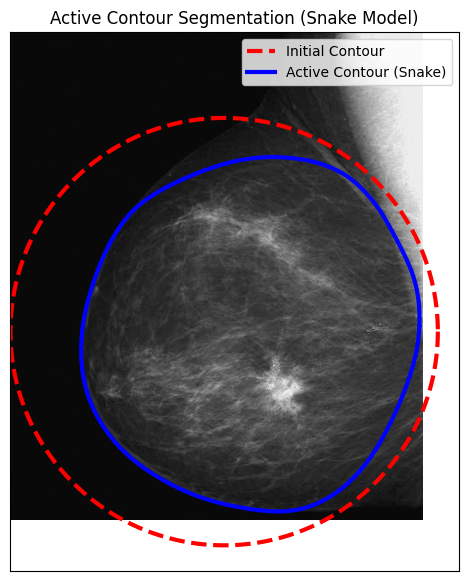

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import data, filters
from skimage.segmentation import active_contour
import cv2

# --- Step 1: Image Preparation ---
# Load the target medical image in grayscale.
# In clinical practice, preprocessing like contrast enhancement may be required.
img = cv2.imread('breastXray.tif', 0)

# --- Step 2: Contour Initialization (Initial Snake) ---
# We define a circular boundary near the object of interest to act as the starting 'Snake'.
# Note: The Snake is a local optimizer; the initial position must be close to the target boundary.
center_y, center_x = 350, 250
radius = 250

# Generate 600 points to ensure high resolution for the contour.
# Increasing the number of points (N=600) allows the snake to fit complex, irregular edges.
s = np.linspace(0, 2*np.pi, 600)
y = center_y + radius * np.sin(s)
x = center_x + radius * np.cos(s)

# Combine into an (N, 2) NumPy array.
# Scikit-image uses the (row, column) format, which corresponds to (y, x).
init_coords = np.array([y, x]).T


# --- Step 3: Execute the Active Contour Algorithm ---
# We apply a Gaussian filter first to smooth noise, which prevents the snake
# from getting stuck in local intensity 'pits' (noise).
#
# Parameter Definitions:
# alpha: Elasticity (Internal Energy). High values make the snake contract like a tight rubber band.
# beta: Smoothness (Internal Energy). High values prevent sharp corners or 'jagged' edges.
# w_line: Attraction to brightness/darkness. Set to 0 if only interested in edges.
# w_edge: Attraction to gradients (External Energy). Set to 1 to pull the snake toward sharp boundaries.
# gamma: Time step for the numerical solver.
snake = active_contour(filters.gaussian(img, 3, preserve_range=False),
                       init_coords,
                       alpha=0.015,
                       beta=10,
                       w_line=0,
                       w_edge=1,
                       gamma=0.001)

# --- Step 4: Result Visualization ---
# We display the original image with both the initial 'seed' contour and the final fitted result.
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, cmap=plt.cm.gray)

# Plotting the red dashed line representing the user-defined starting position
ax.plot(init_coords[:, 1], init_coords[:, 0], '--r', lw=3, label='Initial Contour')

# Plotting the blue solid line representing the converged boundary after energy minimization
ax.plot(snake[:, 1], snake[:, 0], '-b', lw=3, label='Active Contour (Snake)')

# Clean up axes for a professional presentation look
ax.set_xticks([]), ax.set_yticks([])
ax.axis('image')
ax.legend(loc='upper right')
plt.title("Active Contour Segmentation (Snake Model)")

plt.show()

### <font color='cyan'> HW5</font>
1. Read "wood-dowels.tif" \(left\)  
2. Use any method to segment the circles.
3. Display the results (mask).

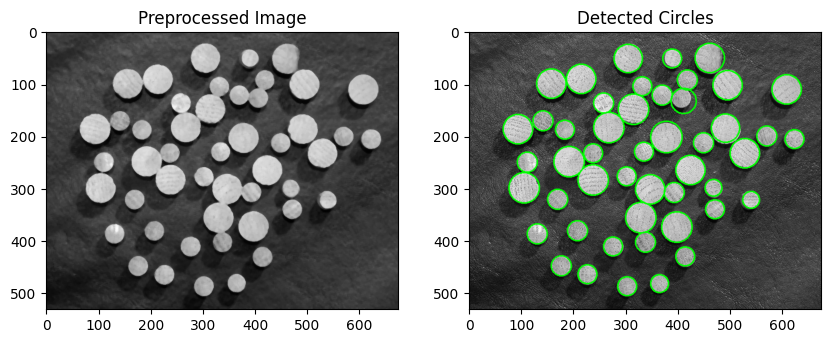

In [ ]:
'''
Please write the code below

'''

import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the image and convert to grayscale
# For medical imaging, this could be a cross-section of a vessel or a tumor
img = cv2.imread('wood-dowels.tif')
if img is None:
    print("Error: Image not found.")
else:
    output = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Preprocessing: Median Blur is often better than Gaussian for circles
    # It removes salt-and-pepper noise while preserving edges
    gray_blurred = cv2.medianBlur(gray, 5)

    # 3. Apply Hough Circle Transform
    # parameters: (image, method, dp, minDist, param1, param2, minRadius, maxRadius)
    circles = cv2.HoughCircles(
        gray_blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,          # Inverse ratio of accumulator resolution
        minDist=40,      # Minimum distance between the centers of detected circles
        param1=100,      # Higher threshold for the internal Canny edge detector
        param2=30,       # Accumulator threshold (smaller = more circles detected)
        minRadius=10,    # Minimum circle radius
        maxRadius=60    # Maximum circle radius
    )

    # 4. Draw the detected circles
    if circles is not None:
        # Convert the (1, N, 3) array to (N, 3) and round to integers
        circles = np.uint16(np.around(circles))
        for i in circles[0, :]:
            # Draw the outer circle (Green)
            cv2.circle(output, (i[0], i[1]), i[2], (0, 255, 0), 2)
            # Draw the center of the circle (Red)
            # cv2.circle(output, (i[0], i[1]), 2, (255, 0, 0), 3)

    # 5. Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(121), plt.imshow(gray_blurred, cmap='gray'), plt.title('Preprocessed Image')
    plt.subplot(122), plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)), plt.title('Detected Circles')
    plt.show()